# Taller S3 · CONECTA S.A., Grupo #

**Curso:** Visualización de Datos y Gerencia de la Información (UNAULA)

**Integrantes:** Maria Camila Grajales Perez, Stiware Alexander Quintero Aguirre, Juan Pablo Ramirez Gomez

**Grupo:** _#1_

## Propósito

Este taller integra las actividades de las sesiones S3 y S4 en un solo entregable. En la **Parte A (S3)** se diagnostican y corrigen los problemas de calidad del dataset de su grupo, aplicando los métodos formales vistos en clase (VIF, missingno, tres métodos de outliers, comparación de imputación). En la **Parte B (S4)** se toma un hallazgo sobre esos datos ya limpios, se verifica que no sea el efecto de una variable de confusión no controlada, y se comunica mediante un SCQA y un gráfico efectivo.

No existe una única forma correcta de limpiar estos datos ni un único hallazgo válido. Lo que se evalúa es que cada decisión esté justificada con un criterio explícito y, donde aplique, con el método formal correspondiente, no que coincida con una respuesta predefinida por el docente.

## Cómo usar este notebook

1. Dupliquen este archivo y renómbrenlo con el número de su grupo (por ejemplo `v0.1_s3_dataviz_grupo3.ipynb`).
2. En la celda de configuración, cambien `GRUPO` por su número (1 a 5) para cargar el archivo correcto.
3. Completen cada actividad en las celdas marcadas con `# TODO`. Las celdas de conclusión siguen el patrón de clase: bullets basados en los números y gráficos efectivamente obtenidos.
4. **Entregables:** este mismo notebook con las dos partes resueltas, más el archivo `dataset_limpio.csv` generado al final de la Parte A.

## 0. Configuración

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import IsolationForest
from sklearn.impute import KNNImputer
import os


pd.set_option("display.float_format", lambda x: f"{x:.2f}")

INDIGO = "#4F46E5"
sns.set_theme(style="whitegrid", font_scale=1.0)

GRUPO = 1  # cambien este número por el de su grupo (1 a 5)

df = pd.read_csv(os.path.join(f"conecta_sa_grupo{GRUPO}.csv"))
df.head()

,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,97400.00,26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,77200.00,10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,59600.00,2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,27700.00,6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,24700.00,7.20,1,27.60,1,Competencia,2026-04-18


### Una función auxiliar que van a necesitar varias veces

`region` y `plan_type` presentan variantes de escritura (mayúsculas, tildes faltantes, espacios adicionales). A continuación, una función auxiliar para normalizarlas, con la misma lógica empleada en el taller de S2:

In [3]:
def normalizar_texto(valor):
    texto = str(valor).strip().upper()
    for con_tilde, sin_tilde in [("Á", "A"), ("É", "E"), ("Í", "I"), ("Ó", "O"), ("Ú", "U")]:
        texto = texto.replace(con_tilde, sin_tilde)
    return texto.title()

# Parte A · Limpieza de datos (S3)

Diagnostiquen y corrijan los problemas de calidad del dataset de su grupo aplicando los métodos formales vistos en clase, en lugar de decisiones basadas solo en inspección visual. El resultado de esta parte es `dataset_limpio.csv`, que también se usa como insumo de la Parte B.

## A1. Diagnóstico cuantificado

**Propósito:** para cada columna del dataset, reporten el porcentaje de nulos. Para las columnas de texto (`region`, `plan_type`), la lista de valores únicos que encuentren con `.unique()` o `.value_counts()`.

In [4]:
# TODO: porcentaje de nulos por columna, ordenado de mayor a menor
print("porcentaje de nulos por columna, ordenado de mayor a menor\n",
      df.isnull().mean().sort_values(ascending=False) * 100)


porcentaje de nulos por columna, ordenado de mayor a menor
 churn_date             97.09
churn_type             97.09
nps_score              80.51
latitud                 1.50
longitud                1.50
tenure_months           0.00
churned                 0.00
complaints_month        0.00
data_usage_gb           0.00
monthly_revenue_cop     0.00
es_cliente_nuevo_mes    0.00
user_id                 0.00
mes                     0.00
plan_type               0.00
tier_localidad          0.00
localidad               0.00
ciudad                  0.00
region                  0.00
pais                    0.00
signup_date             0.00
dtype: float64


In [5]:

# TODO: valores únicos de las columnas de texto
print(df["region"].value_counts())
print(df["plan_type"].value_counts())

region
Andina        269562
Caribe         78041
Pacífica       71120
Orinoquía      20082
Amazonía        8195
Andina          4052
Caribe          1228
Pacifica        1081
Orinoquia        317
Amazonia         125
Name: count, dtype: int64
plan_type
Prepago        177882
Pospago        156014
Convergente    110836
PREPAGO          3596
POSPAGO          3160
CONVERGENTE      2315
Name: count, dtype: int64


**Su conclusión:** 
Las columnas con el porcentaje más alto de nulos son churn_type y churn_date, con el 97.09%, seguidas por nps_score con un valor 80.51%. También, latitud y longitud tienen 1.50% de valores nulos. Las demás columnas no tienen valores faltantes.

En region se encontraron algunas inconsistentes de escritura, como espacios o tildes diferentes, por ejemplo Pacífica y Pacifica y Amazonía y Amazonia. Por lo que fue necesario normalizar sus valores.

En plan_type también se encontraron inconsistencias en el formato, ya que las mismas categorías aparecen con diferente uso de mayúsculas y minúsculas, por ejemplo Prepago y PREPAGO, Pospago y POSPAGO, y Convergente y CONVERGENTE. Por lo tanto, estas categorías también requieren una estandarización antes de continuar con el análisis.

## A2. Multicolinealidad con VIF

**Propósito:** calculen el Variance Inflation Factor (statsmodels) para las variables numéricas de su dataset (`tenure_months`, `monthly_revenue_cop`, `data_usage_gb`, `complaints_month`). ¿Alguna supera el umbral severo de 10? Si no hay colinealidad severa, declárenlo explícitamente, no lo omitan.

In [6]:
# TODO: VIF para tenure_months, monthly_revenue_cop, data_usage_gb, complaints_month
# mismo procedimiento visto en clase: sm.add_constant, variance_inflation_factor por columna

# A2. Multicolinealidad con VIF



# Seleccionar las variables indicadas
variables_vif = [
    "tenure_months",
    "monthly_revenue_cop",
    "data_usage_gb",
    "complaints_month"
]

X = df[variables_vif].dropna()

# Agregar constante
X_const = sm.add_constant(X)

# Calcular VIF para cada variable
vif = pd.DataFrame({
    "Variable": variables_vif,
    "VIF": [
        variance_inflation_factor(X_const.values, i + 1)
        for i in range(len(variables_vif))
    ]
})

# Ordenar de mayor a menor
vif = vif.sort_values("VIF", ascending=False)

display(vif)


,Variable,VIF
3,complaints_month,1.04
2,data_usage_gb,1.04
1,monthly_revenue_cop,1.00
0,tenure_months,1.00


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
 
barras = ax.bar(
    vif["Variable"],
    vif["VIF"],
    color="#87BBD7",       # Powder Blue
    edgecolor="none",
    width=0.6
)
 
# Línea de referencia para multicolinealidad severa
ax.axhline(
    y=10,
    color="#DAF561",       # Chartreuse
    linestyle="--",
    linewidth=2.5,
    label="Umbral severo (VIF = 10)"
)
 
# Mostrar valores encima de las barras
for barra, valor in zip(barras, vif["VIF"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.05,
        f"{valor:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#132441"
    )
 
ax.set_title(
    "Factor de Inflación de la Varianza (VIF)",
    fontsize=16,
    fontweight="bold",
    color="#132441",
    pad=15
)
 
ax.set_xlabel("Variable", fontsize=11, color="#132441")
ax.set_ylabel("VIF", fontsize=11, color="#132441")
 
# Diseño minimalista
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
 
# Colores de los ejes
ax.tick_params(axis="both", colors="#132441")
 
ax.legend(
    frameon=False,
    fontsize=10
)
 
plt.xticks(rotation=15, ha="right", rotation_mode="anchor")
 
plt.tight_layout()
plt.show()

**Su conclusión:** _(VIF de cada variable, si alguna supera 10 o 5; si no hay colinealidad severa, declárenlo explícitamente)_

## A3. Patrón de ausencia con missingno

**Propósito:** usen `msno.matrix` sobre el dataset completo. Como `nps_score` tiene muchos más nulos que cualquier otra columna (~80%), ¿el patrón visual sugiere que la ausencia se concentra en algún tramo del archivo, o está dispersa?

<Axes: >

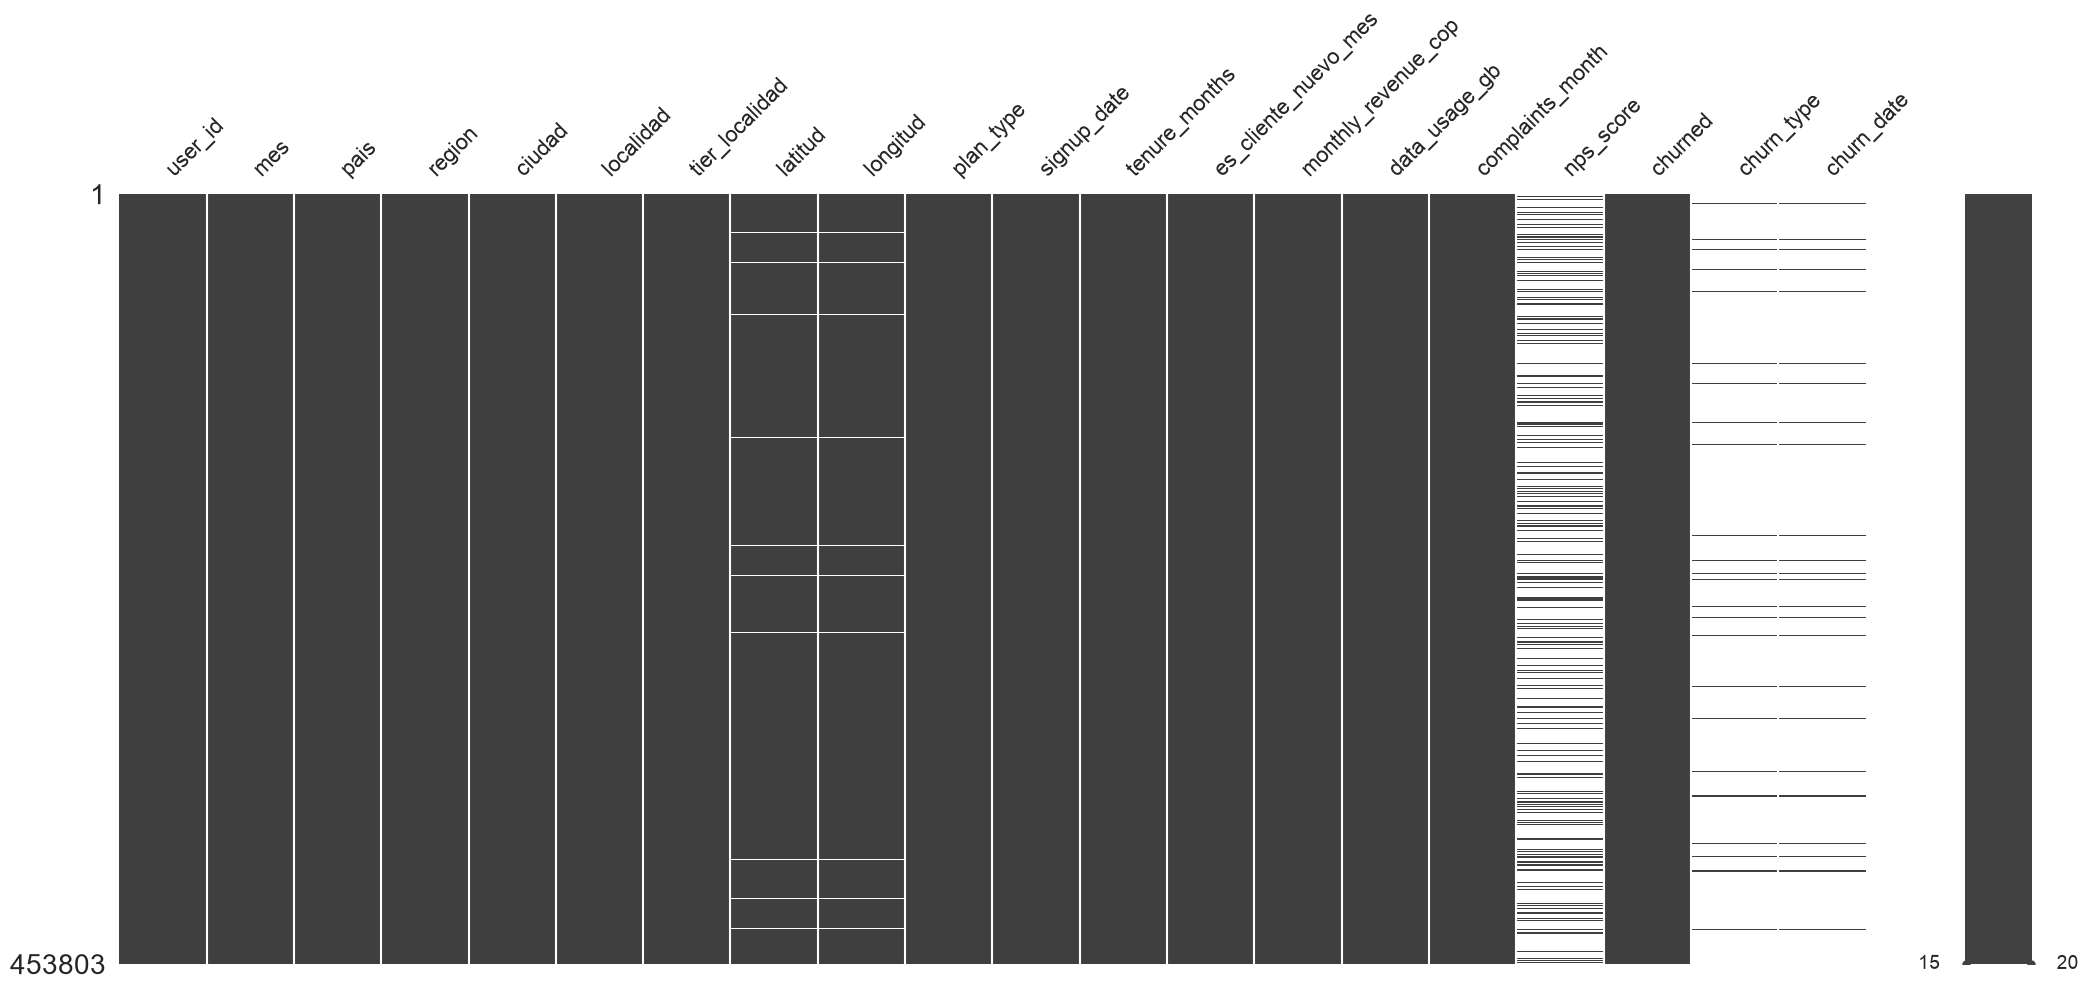

In [8]:
# TODO: msno.matrix(df)
msno.matrix(df)

**Su conclusión:** _(qué muestra la matriz sobre el patrón de ausencia de `nps_score` y de las demás columnas)_

## A4. Coordenadas

**Propósito:** revisen `latitud` y `longitud`. Colombia está aproximadamente entre 0° y 13° de latitud norte, y entre -66° y -80° de longitud. Identifiquen nulos, valores en (0, 0), y valores fuera de rango. Decidan qué hacer con cada tipo de problema.

In [35]:
# TODO: nulos en latitud/longitud
# TODO: valores en (0, 0), "null island"
# TODO: valores fuera de rango de Colombia (latitud 0-13, longitud -80 a -66)
nulos_coordenadas = df[["latitud", "longitud"]].isnull().sum()
 
# Filas con al menos una coordenada nula
filas_con_nulos = df[
    df["latitud"].isna() | df["longitud"].isna()
]
 
# 2. Valores en (0, 0) - "Null Island"
null_island = df[
    (df["latitud"] == 0) &
    (df["longitud"] == 0)
]
 
# 3. Valores fuera del rango lógico de Colombia
fuera_rango = df[
    (df["latitud"] < 0) |
    (df["latitud"] > 13) |
    (df["longitud"] < -80) |
    (df["longitud"] > -66)
]
 
# Mostrar resultados
print("NULOS POR COLUMNA")
print(nulos_coordenadas)
 
print("\nFilas con al menos una coordenada nula:", len(filas_con_nulos))
print("Valores en (0, 0) - Null Island:", len(null_island))
print("Valores fuera del rango de Colombia:", len(fuera_rango))
resumen_coordenadas = pd.DataFrame({
    "Problema": [
        "Latitud nula",
        "Longitud nula",
        "Al menos una coordenada nula",
        "Coordenadas en (0, 0)",
        "Coordenadas fuera del rango de Colombia"
    ],
    "Cantidad": [
        df["latitud"].isna().sum(),
        df["longitud"].isna().sum(),
        len(filas_con_nulos),
        len(null_island),
        len(fuera_rango)
    ]
})
 
resumen_coordenadas["Porcentaje"] = (
    resumen_coordenadas["Cantidad"] / len(df) * 100
).round(2)
 
display(resumen_coordenadas)

NULOS POR COLUMNA
latitud     6805
longitud    6805
dtype: int64

Filas con al menos una coordenada nula: 6805
Valores en (0, 0) - Null Island: 1362
Valores fuera del rango de Colombia: 6446


,Problema,Cantidad,Porcentaje
0,Latitud nula,6805,1.50
1,Longitud nula,6805,1.50
2,Al menos una coordenada nula,6805,1.50
3,"Coordenadas en (0, 0)",1362,0.30
4,Coordenadas fuera del rango de Colombia,6446,1.42


**Su conclusión:** Coordenadas nulas: Se identificaron 685 registros con coordenadas nulas. Se decidió marcarlos inicialmente como valores faltantes y no eliminarlos, ya que el dataset cuenta con información geográfica adicional con la que puede diligenciarse. Posteriormente, pueden imputarse utilizando las coordenadas representativas de registros pertenecientes a la misma localidad o, si no fuera posible, a la misma ciudad. Por ejemplo, si un usuario de Bogotá tiene latitud y longitud nulas, se podría calcular la mediana de las coordenadas válidas de los demás registros de Bogotá y utilizar esos valores para completar su ubicación.
 
Coordenadas en (0, 0): Se encontraron 1.362 registros con coordenadas (0, 0). Debido a que esta ubicación no corresponde a una posición válida para Colombia, se decidió convertir estos valores en coordenadas faltantes. Posteriormente, podrán tratarse de la misma manera que los nulos e imputarse utilizando la información de localidad o ciudad. Por ejemplo, si un registro tiene (0, 0) pero pertenece a una determinada localidad, se podría reemplazar por la mediana de las coordenadas válidas de los demás usuarios registrados en esa misma localidad.
 
Coordenadas fuera del rango de Colombia: Se identificaron 646 registros con coordenadas fuera del rango geográfico establecido para Colombia. Se decidió marcarlos como inválidos y revisar si es posible recuperar o corregir su ubicación utilizando las variables pais, region, ciudad y localidad. Por ejemplo, si un registro indica que pertenece a Bogotá, pero sus coordenadas están fuera del rango de Colombia, se pueden comparar con las coordenadas válidas de otros registros de Bogotá para evaluar una posible corrección. Si no pueden corregirse de manera confiable, estos registros se excluirán únicamente de los análisis geográficos, conservando el resto de su información para otros análisis.

## A5. Texto inconsistente

**Propósito:** normalicen `region` y `plan_type` a un conjunto único de valores. Documenten qué variantes encontraron antes de unificarlas.

In [10]:
# TODO: apliquen normalizar_texto() a region y plan_type
# antes de sobreescribir, comparen value_counts() de antes vs. después para documentar las variantes
print("Valores antes de normalizar")
print("Region:\n",df["region"].value_counts())
print("\nPlan_type:\n",df["plan_type"].value_counts())

Valores antes de normalizar
Region:
 region
Andina        269562
Caribe         78041
Pacífica       71120
Orinoquía      20082
Amazonía        8195
Andina          4052
Caribe          1228
Pacifica        1081
Orinoquia        317
Amazonia         125
Name: count, dtype: int64

Plan_type:
 plan_type
Prepago        177882
Pospago        156014
Convergente    110836
PREPAGO          3596
POSPAGO          3160
CONVERGENTE      2315
Name: count, dtype: int64


In [11]:

print("\nValores despues de normalizar")
df['region'] = df['region'].apply(lambda x: normalizar_texto(x))
df['plan_type'] = df['plan_type'].apply(lambda x: normalizar_texto(x))
# Impresión
print("Region:\n",df["region"].value_counts())
print("\nPlan_type:\n",df["plan_type"].value_counts())


Valores despues de normalizar
Region:
 region
Andina       273614
Caribe        79269
Pacifica      72201
Orinoquia     20399
Amazonia       8320
Name: count, dtype: int64

Plan_type:
 plan_type
Prepago        181478
Pospago        159174
Convergente    113151
Name: count, dtype: int64


**Su conclusión:**

En region se encontraron 10 valores distintos, que realmente corresponden a solo 5 regiones. Las diferencias estaban en tildes, por ejemplo, Pacífica y Pacifica. Después de aplicar la normalización, las categorías se unificaron en 5 valores: Andina, Caribe, Pacifica, Orinoquia y Amazonia.
 
En plan_type se identificaron 6 valores distintos que correspondían realmente a 3 categorías, debido a inconsistencias en las mayúsculas y minúsculas. Por ejemplo, Prepago y PREPAGO. Después de normalizar los valores, quedaron únicamente las categorías Prepago, Pospago y Convergente.
 
La normalización permitió unificar etiquetas equivalentes sin modificar la cantidad de registros, ya que el total se mantuvo sin eliminar ni duplicar registros.

## A6. Duplicados

**Propósito:** verifiquen si hay filas exactamente duplicadas. Antes de eliminarlas, confirmen que realmente son duplicados de carga y no dos eventos legítimos del mismo usuario en el mismo mes.

In [ ]:
# TODO: df.duplicated().sum()
# TODO: revisen si los duplicados coinciden en user_id + mes, o son coincidencias parciales en otras columnas
df.duplicated().sum()

duplicados_exactos = df.duplicated().sum()
 
print("Cantidad de filas exactamente duplicadas:", duplicados_exactos)
 
# Obtener todas las filas que pertenecen a grupos de duplicados exactos
df_duplicados = df[df.duplicated(keep=False)]
 
# Revisar si los duplicados coinciden en user_id + mes
resumen_duplicados = (
    df_duplicados
    .groupby(["user_id", "mes"])
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)
 
print("\nCombinaciones repetidas de user_id + mes:")
display(resumen_duplicados.head(10))
 
# Verificar cuántas combinaciones tienen más de un registro
cantidad_repetidos = (resumen_duplicados["cantidad"] > 1).sum()
 
print(
    "\nCantidad de combinaciones user_id + mes repetidas:",
    cantidad_repetidos
)



Cantidad de filas exactamente duplicadas: 1355

Combinaciones repetidas de user_id + mes:


,user_id,mes,cantidad
0,CNX-100180,2026-04,2
900,CNX-201915,2026-03,2
908,CNX-202262,2026-05,2
907,CNX-202213,2026-05,2
906,CNX-202153,2026-03,2
905,CNX-202089,2026-04,2
904,CNX-202089,2026-03,2
903,CNX-202082,2026-04,2
902,CNX-202047,2026-03,2
901,CNX-201922,2026-05,2



Cantidad de combinaciones user_id + mes repetidas: 1355


In [37]:
df_sin_duplicados = df.drop_duplicates()
 
print("Filas antes:", len(df))
print("Filas después:", len(df_sin_duplicados))
print("Duplicados eliminados:", len(df) - len(df_sin_duplicados))

Filas antes: 453803
Filas después: 452448
Duplicados eliminados: 1355


**Su conclusión:** _Se encontraron 1.355 filas exactamente duplicadas. Se concluyó que son duplicados de carga y no eventos legítimos porque cada fila identificada como duplicada coincide exactamente en todas las columnas del dataset, no solo en user_id y mes. Además, al revisar estas filas, se observó que las combinaciones de user_id + mes aparecen repetidas con una cantidad de 2, pero sin presentar diferencias en ninguna de las demás variables. Por lo tanto, no existe evidencia de que representen dos eventos distintos, sino que corresponden a la misma información registrada dos veces._

## A7. El caso de `nps_score`: ¿por qué falta?

**Propósito:** calculen el % de nulos en `nps_score`, y compárenlo entre usuarios con `churned=1` y `churned=0`. En clase vieron tres tipos de ausencia (MCAR, MAR, MNAR): usen esa comparación, junto con lo que ya saben del negocio de CONECTA, para argumentar cuál de los tres aplica aquí y por qué, no solo para reportar el número. Con esa conclusión, justifiquen por escrito qué van a hacer con la columna: ¿la imputan, dejan el nulo, o la excluyen de ciertos análisis?

In [13]:
# TODO: % de nulos en nps_score, total y por grupo de churned (0 vs 1)

**Su conclusión:** _(el % de nulos por grupo, si es MCAR/MAR/MNAR según ese indicio, y qué decidieron hacer con la columna)_

## A8. Outliers: tres métodos, no uno solo

**Propósito:** apliquen a `monthly_revenue_cop` los tres métodos vistos en clase: Tukey (Q1-1.5×IQR a Q3+1.5×IQR), Modified Z-score con MAD (Iglewicz & Hoaglin, 1993, umbral 3.5), e Isolation Forest (multivariado, sobre `monthly_revenue_cop`, `data_usage_gb`, `complaints_month`). Comparen los tres conjuntos de outliers: ¿coinciden en gran medida, o cada método señala casos distintos? Relacionen la diferencia con lo que ya observaron sobre estas variables en el correlograma del taller de S2.

In [14]:
# TODO: Tukey IQR sobre monthly_revenue_cop
# TODO: Modified Z-score (MAD) sobre monthly_revenue_cop
# TODO: Isolation Forest sobre monthly_revenue_cop, data_usage_gb, complaints_month

**Su conclusión:** _(cuántos outliers detectó cada método, y en qué medida coinciden o difieren entre sí)_

## A9. Imputación comparada, si aplica

**Propósito:** si su grupo decide imputar algún valor (no necesariamente coordenadas), comparen al menos dos métodos (por ejemplo mediana por grupo vs. KNN) con un gráfico de densidades superpuestas antes de aplicar uno. Si el dataset no requiere imputación en ninguna columna numérica, documenten por qué no es necesaria, en vez de omitir el punto.

In [15]:
# TODO: si aplica, comparen al menos 2 métodos de imputación con un gráfico de densidades superpuestas
# (sns.kdeplot de la variable original sin nulos contra cada método candidato)

**Su conclusión:** _(qué columna imputaron y con qué método, o por qué no fue necesario imputar nada)_

## A10. Documentación de decisiones

**Propósito:** por cada corrección aplicada, una línea: qué se encontró, qué método formal se usó (si aplica), qué se decidió, y por qué.

| problema encontrado | método formal usado | decisión | por qué |
|---|---|---|---|
| | | | |
| | | | |
| | | | |
| | | | |
| | | | |
| | | | |

In [17]:
# TODO: apliquen aquí todas las correcciones que decidieron arriba, sobre una copia del dataframe
df_limpio = df.copy()

# ...

df_limpio.to_csv(os.path.join("", "dataset_limpio.csv"), index=False)
print("Nulos restantes:", df_limpio.isnull().sum().sum())
df_limpio.head()

Nulos restantes: 1260109


,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,97400.00,26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,77200.00,10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,59600.00,2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,27700.00,6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,24700.00,7.20,1,27.60,1,Competencia,2026-04-18


## Entregable Parte A

`dataset_limpio.csv` (ya guardado arriba) más la tabla de decisiones del punto A10 completa.

# Parte B · SCQA y diseño efectivo (S4)

Tomen un hallazgo sobre `dataset_limpio.csv` (generado en la Parte A), verifiquen que se sostenga al considerar otra variable relevante, y comuníquenlo mediante un SCQA y un gráfico efectivo. El centro de esta parte es el SCQA y una primera versión del gráfico que lo sostenga: no tiene que ser la versión final, la van a seguir refinando en sesiones posteriores del curso. El heatmap de `region` x `tier_localidad` y el choropleth construidos en el taller de S2 ya sugieren que ambas dimensiones no son independientes entre sí; tengan esto presente al elegir qué variable considerar.

In [19]:
df = pd.read_csv(os.path.join("", "dataset_limpio.csv"))
df.head()

,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,97400.00,26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,77200.00,10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,59600.00,2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,27700.00,6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,24700.00,7.20,1,27.60,1,Competencia,2026-04-18


## B1. Hallazgo y verificación

**Propósito:** identifiquen un hallazgo relevante para CONECTA (por ejemplo, una diferencia en `churned` o en `monthly_revenue_cop` asociada a alguna variable). Verifíquenlo considerando al menos una variable adicional (`region`, `tier_localidad`, `mes`, `plan_type`), con el método que corresponda a su pregunta: regresión, comparación de tasas o promedios, tabla cruzada. No todo hallazgo requiere un modelo. Reporten si el hallazgo se sostiene, se debilita, o desaparece al considerar esa variable.

In [ ]:
# TODO: identifiquen un hallazgo (comparación, correlación o modelo simple, según corresponda)
# TODO: verifíquenlo considerando al menos una variable adicional relevante

**Su conclusión:** _(cuál es el hallazgo, y si se sostiene o cambia al considerar la variable adicional)_

## B2. Escribir el SCQA

**Propósito:** con el hallazgo ya verificado, escriban el SCQA antes de tocar el código del gráfico.

**Situación:** _(contexto que cualquier persona en CONECTA acepta como punto de partida)_

**Complicación:** _(qué cambió o qué tensión rompe esa situación)_

**Pregunta:** _(la pregunta implícita que deja la complicación)_

**Respuesta:** _(la conclusión que su gráfico va a sostener, basada en el hallazgo verificado de B1)_

## B3. Primera versión del gráfico efectivo

**Propósito:** construyan una primera versión del gráfico que sostenga la Respuesta del SCQA, aplicando al menos cuatro principios de diseño: tinta proporcional, manejo de superposición si aplica, color con propósito (no arcoíris), codificación redundante si ayuda a accesibilidad, eliminación de desorden, balance dato-contexto. El título debe ser, literalmente, la Respuesta del SCQA. Es un primer intento (MVP), no la versión final: la van a seguir refinando en sesiones posteriores del curso.

In [ ]:
# TODO: primera versión del gráfico, con el título = la Respuesta del SCQA
# marquen en un comentario cuáles principios aplicaron

**Su conclusión:** _(qué principios aplicaron, y qué le falta pulir en próximas versiones)_

## Entregable Parte B

El hallazgo verificado, el SCQA escrito, y la primera versión del gráfico efectivo (código incluido), con los principios de diseño aplicados documentados.

## Entregable completo de este taller

Este mismo notebook (`v0.1_s3_dataviz_grupoN.ipynb`, con su número de grupo), con la Parte A y la Parte B resueltas, más el archivo `dataset_limpio.csv` generado en A10. Antes de entregar, revisen que cada conclusión esté basada en los números y gráficos efectivamente obtenidos, y no en lo que esperaban encontrar.